<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/03_NHANES_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Dataset 03: NHANES (National Health and Nutrition Examination Survey)

## 📋 Descripción del Dataset
Este dataset contiene datos demográficos recolectados por el CDC de EE. UU. durante el ciclo 2017-2018.
* **Archivo utilizado:** `DEMO_J.xpt` (Demographic Variables).
* **Objetivo:** Preparar una base demográfica para análisis predictivos (Ej: Clasificación de género `RIAGENDR`).
* **Dimensiones:** Aproximadamente 9254 filas y 46 columnas.

## 🛠️ Archivos en esta carpeta
* `DEMO_J.xpt`: Archivo de transporte SAS con los datos crudos.
* `03_NHANES_Analysis.ipynb`: Cuaderno de Colab con el proceso de carga y limpieza.

## ⚙️ Trabajo y Preparación de Datos
1. **Carga Especializada:** Uso de `pd.read_sas` para manejar el formato `.xpt`.
2. **Decodificación:** Conversión de datos de formato bytes a UTF-8.
3. **Limpieza:** Eliminación del identificador de secuencia `SEQN`.
4. **Tratamiento de Nulos:** Imputación por **Media** (numéricos) y **Moda** (categóricos).
5. **Normalización:** Aplicación de Z-Score manual para estandarizar las escalas de edad y otros indicadores.

---
*Preparación realizada para la Primera Parte del Examen Parcial.*

In [ ]:
# ==============================================================================
# 1. CONEXIÓN Y LIBRERÍAS
# ==============================================================================
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
print("Librerías cargadas correctamente.")

Mounted at /content/gdrive
Librerías cargadas correctamente.


In [ ]:
# ==============================================================================
# 2. CARGA DE DATOS (Formato SAS .XPT)
# ==============================================================================
# Ruta exacta de tu archivo .xpt
ruta_nhanes = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/03_NHANES/DEMO_J.xpt'

# Usamos read_sas para este formato específico
df = pd.read_sas(ruta_nhanes)

# NHANES suele cargar los datos como tipo 'bytes', los convertimos a números/texto estándar
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode('utf-8')

print("="*70)
print(f"DATASET NHANES CARGADO: {df.shape[0]} filas y {df.shape[1]} columnas")
print("="*70)
display(df.head(3))

DATASET NHANES CARGADO: 9254 filas y 46 columnas


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,5.0,5.0,3.000000e+00,5.397605e-79,5.397605e-79,1.0,2.0,3.0,1.0,3.0,9246.491865,8539.731348,2.0,145.0,15.0,15.0,5.00
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,4.0,4.0,2.000000e+00,5.397605e-79,5.397605e-79,1.0,2.0,3.0,1.0,2.0,37338.768343,42566.614750,1.0,143.0,15.0,15.0,5.00
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,2.0,3.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,1.000000e+00,2.0,4.0,1.0,2.0,NaN,8614.571172,8338.419786,2.0,145.0,3.0,3.0,0.82


In [ ]:
# ==============================================================================
# 3. ANTES Y DESPUÉS: TRATAMIENTO DE NULOS
# ==============================================================================
print("="*70)
print(" FASE 1: TRATAMIENTO DE VALORES NULOS")
print("="*70)

# ANTES
nulos_antes = df.isnull().sum()
columnas_con_nulos = nulos_antes[nulos_antes > 0]
print("\n🔴 [ANTES] Columnas con datos faltantes (Top 10):")
print(columnas_con_nulos.sort_values(ascending=False).head(10).to_string())

# PROCESO: Llenar nulos
for columna in df.columns:
    if df[columna].dtype == 'object':
        df[columna] = df[columna].fillna(df[columna].mode()[0])
    else:
        df[columna] = df[columna].fillna(df[columna].mean())

# DESPUÉS
print(f"\n🟢 [DESPUÉS] Total de nulos restantes: {df.isnull().sum().sum()} ✅")

 FASE 1: TRATAMIENTO DE VALORES NULOS

🔴 [ANTES] Columnas con datos faltantes (Top 10):
DMQADFC     8693
RIDAGEMN    8657
RIDEXPRG    8144
DMDYRSUS    7306
DMDEDUC3    6948
RIDEXAGM    5821
DMDHSEDZ    4503
AIALANGA    4277
DMDMARTL    3685
DMDEDUC2    3685

🟢 [DESPUÉS] Total de nulos restantes: 0 ✅


In [ ]:
# ==============================================================================
# 4. CODIFICACIÓN Y LIMPIEZA
# ==============================================================================
# Eliminamos SEQN (ID de secuencia) que no tiene valor predictivo
if 'SEQN' in df.columns:
    df = df.drop('SEQN', axis=1)

print("="*70)
print(" FASE 2: CODIFICACIÓN DE VARIABLES")
print("="*70)

# NHANES a veces tiene variables que parecen números pero son categorías
# (Ej: 1=Hombre, 2=Mujer). LabelEncoder se encargará de normalizar todo.
columnas_codificar = df.columns.tolist()

encoder = LabelEncoder()
for columna in columnas_codificar:
    df[columna] = encoder.fit_transform(df[columna].astype(str))

print("\n🟢 [RESULTADO] Primeras 3 filas del dataset preparado:")
display(df.head(3))

 FASE 2: CODIFICACIÓN DE VARIABLES

🟢 [RESULTADO] Primeras 3 filas del dataset preparado:


,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,0,1,1,11,2,4,4,2,160,1,1,0,0,10,13,3,2,2,0,0,1,0,2,2,1,1,1,1,4,4,2,3,3,0,1,3,0,3,7797,7236,1,11,6,6,444
1,0,1,0,11,2,2,2,0,167,1,1,0,0,10,13,3,2,2,0,0,1,0,2,2,1,1,1,1,3,3,1,3,3,0,1,3,0,1,5471,5600,0,9,6,6,444
2,0,1,1,63,2,3,3,2,10,2,1,0,0,10,13,1,3,2,0,1,1,0,2,2,0,2,2,0,0,0,3,3,0,1,3,0,2,2,7579,7151,1,11,8,8,79


In [ ]:
# ==============================================================================
# 5. MATRIZ FINAL Y NORMALIZACIÓN
# ==============================================================================
# En NHANES (Demographics), un objetivo común es predecir RIAGENDR (Género)
# o RIDRETH1 (Etnia). Usaremos RIAGENDR como 'y'.
target = 'RIAGENDR' if 'RIAGENDR' in df.columns else df.columns[-1]

X = df.drop(target, axis=1).values
y = df[target].values

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print(f"\n¡MATRIZ X_norm CREADA! Objetivo (y): {target}")
print(f"Forma final: {X_norm.shape}")


¡MATRIZ X_norm CREADA! Objetivo (y): RIAGENDR
Forma final: (9254, 44)


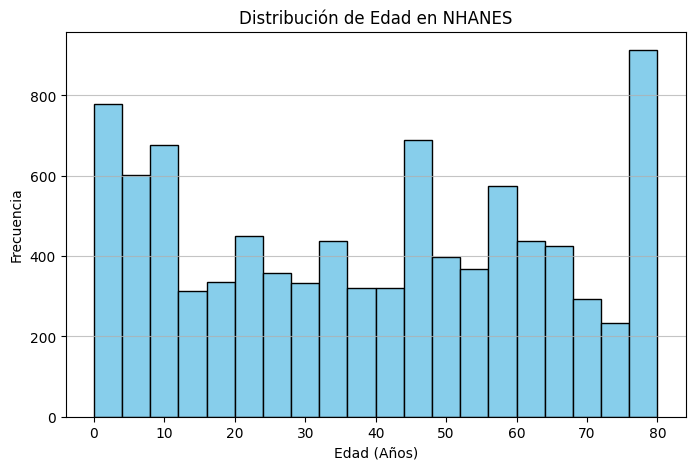

In [ ]:
# ==============================================================================
# 6. VISUALIZACIÓN EXPLORATORIA
# ==============================================================================
# RIDAGEYR es la edad en años en NHANES
col_x = 'RIDAGEYR' if 'RIDAGEYR' in df.columns else df.columns[0]

plt.figure(figsize=(8, 5))
plt.hist(df[col_x], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de Edad en NHANES')
plt.xlabel('Edad (Años)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()